In [13]:
"""
De los bordes a la textura

En los notebooks anteriores, nos centramos en métodos basados ​​en edge(bordes), como los filtros Sobel, Laplaciano y Canny. Estos métodos son útiles para detectar límites e interfaces.
Sin embargo, en muchos problemas de imagenes, la información más importante no es solo dónde están los límites, sino también cómo se organizan espacialmente los valores de intensidad dentro de una región.

Esta es la idea de textura.

- La intensidad describe el valor de un píxel.
- Los bordes describen transiciones abruptas.
- La textura describe patrones espaciales locales.
"""

'\nDe los bordes a la textura\n\nEn los notebooks anteriores, nos centramos en métodos basados \u200b\u200ben edge(bordes), como los filtros Sobel, Laplaciano y Canny. Estos métodos son útiles para detectar límites e interfaces.\nSin embargo, en muchos problemas de imagenes, la información más importante no es solo dónde están los límites, sino también cómo se organizan espacialmente los valores de intensidad dentro de una región.\n\nEsta es la idea de textura.\n\n- La intensidad describe el valor de un píxel.\n- Los bordes describen transiciones abruptas.\n- La textura describe patrones espaciales locales.\n'

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage import data, color, util
from skimage.measure import shannon_entropy
from scipy.ndimage import uniform_filter
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [15]:
np.random.seed(42)
"""
Definimos algunas funciones de utilidad para:
- mostrar imágenes
- calcular la varianza local
- extraer descriptores de textura simples
- crear pequeños conjuntos de datos de texturas sintéticas
"""


'\nDefinimos algunas funciones de utilidad para:\n- mostrar imágenes\n- calcular la varianza local\n- extraer descriptores de textura simples\n- crear pequeños conjuntos de datos de texturas sintéticas\n'

In [16]:
def show_images(images, titles, cmap='gray', figsize=(14, 8)):
    n = len(images)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()


def local_variance(image, size=7):
    image = image.astype(np.float32)
    mean = uniform_filter(image, size=size)
    mean_sq = uniform_filter(image**2, size=size)
    return mean_sq - mean**2


def extract_basic_texture_features(image):
    image = image.astype(np.float32)
    feats = {
        "mean": float(np.mean(image)),
        "std": float(np.std(image)),
        "min": float(np.min(image)),
        "max": float(np.max(image)),
        "entropy": float(shannon_entropy(image)),
        "local_variance_mean": float(np.mean(local_variance(image, size=7))),
        "local_variance_std": float(np.std(local_variance(image, size=7))),
    }
    return feats

In [17]:
images = [uniform, noise, stripes, checkerboard, smoothed_noise, granular]
titles = [
    "Uniform",
    "Random noise",
    "Stripes",
    "Checkerboard",
    "Smoothed noise",
    "Granular texture"
]

In [18]:
"""
Ejemplos de texturas sintéticas

Comenzamos con ejemplos sintéticos sencillos para desarrollar la intuición.

Estos ejemplos son útiles porque aíslan el concepto de textura:
- Región uniforme
- Ruido aleatorio
- Rayas periódicas
- Patrón de tablero de ajedrez
- Ruido suavizado
- Textura granular
"""

'\nEjemplos de texturas sintéticas\n\nComenzamos con ejemplos sintéticos sencillos para desarrollar la intuición.\n\nEstos ejemplos son útiles porque aíslan el concepto de textura:\n- Región uniforme\n- Ruido aleatorio\n- Rayas periódicas\n- Patrón de tablero de ajedrez\n- Ruido suavizado\n- Textura granular\n'

In [19]:
size = 150

uniform = np.ones((size, size)) * 0.5

noise = np.random.rand(size, size)

x = np.arange(size)
y = np.arange(size)
xx, yy = np.meshgrid(x, y)

stripes = ((xx // 10) % 2).astype(float)

checkerboard = (((xx // 8) + (yy // 8)) % 2).astype(float)

smoothed_noise = uniform_filter(np.random.rand(size, size), size=9)

granular = uniform_filter(np.random.rand(size, size), size=3) + 0.3 * np.random.rand(size, size)
granular = (granular - granular.min()) / (granular.max() - granular.min())


In [20]:
def show_images(images, titles, cmap='gray', figsize=(14, 8), save_path=None):
    n = len(images)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    
    for ax in axes[len(images):]:
        ax.axis('off')
    
    plt.tight_layout()

    # 👉 GUARDAR ANTES DE SHOW
    if save_path is not None:
        import os
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    print(len(images))



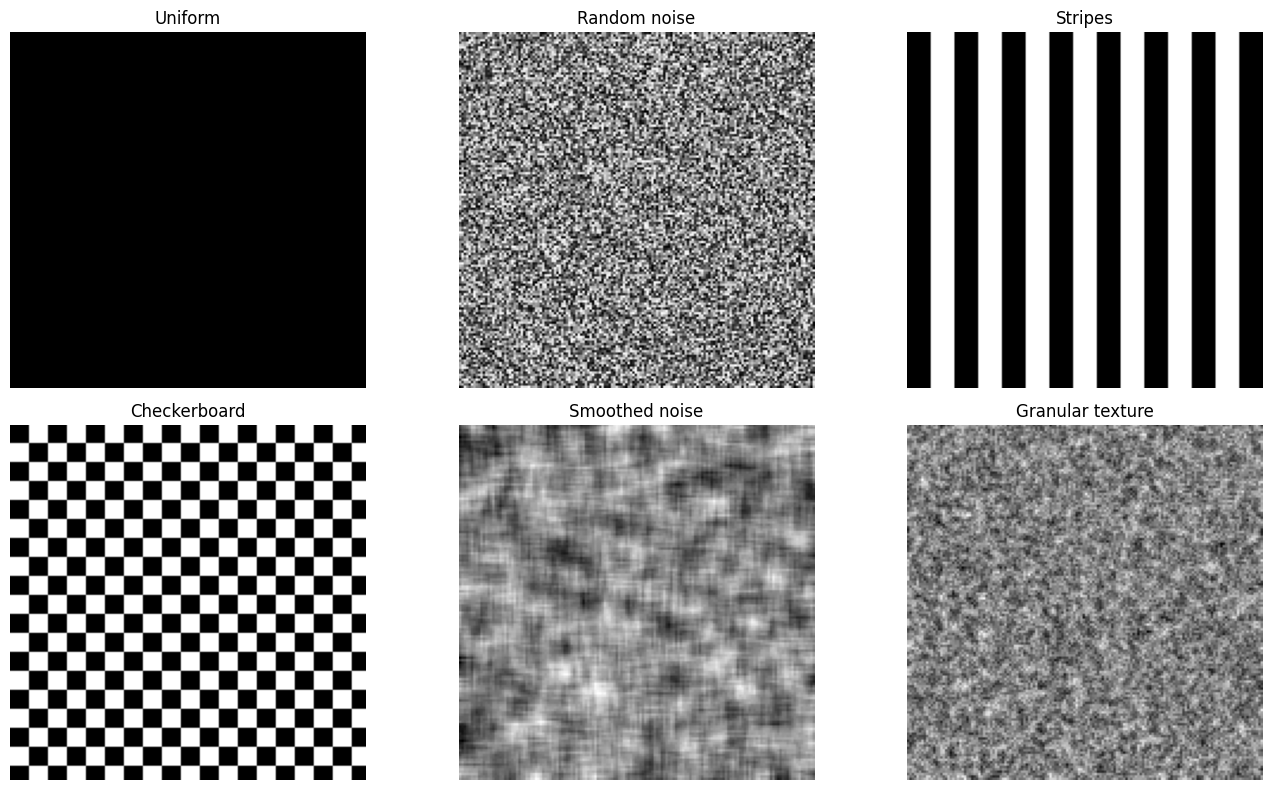

6


In [21]:
show_images(
    images,
    titles,
    figsize=(14, 8),
    save_path="../figures/figures_texture/synthetic_texture_images.png"
)

In [22]:
basic_stats = []

for img, title in zip(images, titles):
    stats = extract_basic_texture_features(img)
    stats["texture"] = title
    basic_stats.append(stats)

df_stats = pd.DataFrame(basic_stats)
df_stats = df_stats[["texture", "mean", "std", "entropy", "local_variance_mean", "local_variance_std", "min", "max"]]
df_stats



,texture,mean,std,entropy,local_variance_mean,local_variance_std,min,max
0,Uniform,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000
1,Random noise,0.501112,0.289444,14.456926,0.082039,0.010730,0.000040,0.999978
2,Stripes,0.466667,0.498888,0.996792,0.106667,0.101936,0.000000,1.000000
3,Checkerboard,0.499200,0.499999,0.999998,0.199053,0.071344,0.000000,1.000000
4,Smoothed noise,0.500211,0.032364,14.449282,0.000448,0.000247,0.375377,0.611622
5,Granular texture,0.499851,0.140165,14.455682,0.017843,0.004476,0.000000,1.000000


In [23]:
"""
Interpretación de descriptores básicos de textura

Incluso los descriptores más sencillos revelan diferencias importantes:

- La media mide la intensidad promedio.
- La desviación estándar mide la variabilidad global.
- La entropía mide la complejidad o aleatoriedad.
- La varianza local mide la heterogeneidad espacial.

Estos descriptores siguen siendo sencillos, pero ya van más allá de la detección de bordes.
"""

'\nInterpretación de descriptores básicos de textura\n\nIncluso los descriptores más sencillos revelan diferencias importantes:\n\n- La media mide la intensidad promedio.\n- La desviación estándar mide la variabilidad global.\n- La entropía mide la complejidad o aleatoriedad.\n- La varianza local mide la heterogeneidad espacial.\n\nEstos descriptores siguen siendo sencillos, pero ya van más allá de la detección de bordes.\n'

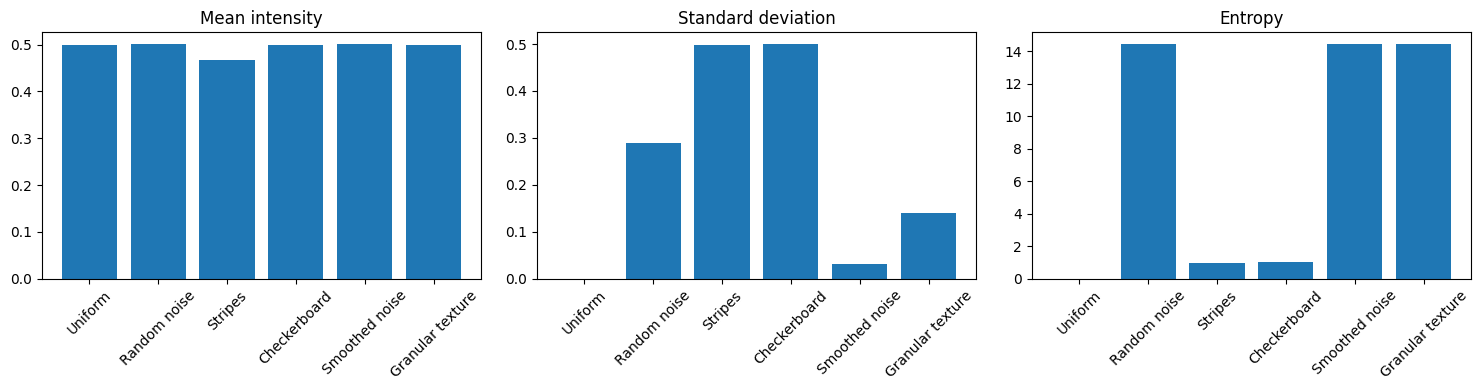

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(df_stats["texture"], df_stats["mean"])
axes[0].set_title("Mean intensity")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(df_stats["texture"], df_stats["std"])
axes[1].set_title("Standard deviation")
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(df_stats["texture"], df_stats["entropy"])
axes[2].set_title("Entropy")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../figures/figures_texture/syntetic_image_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


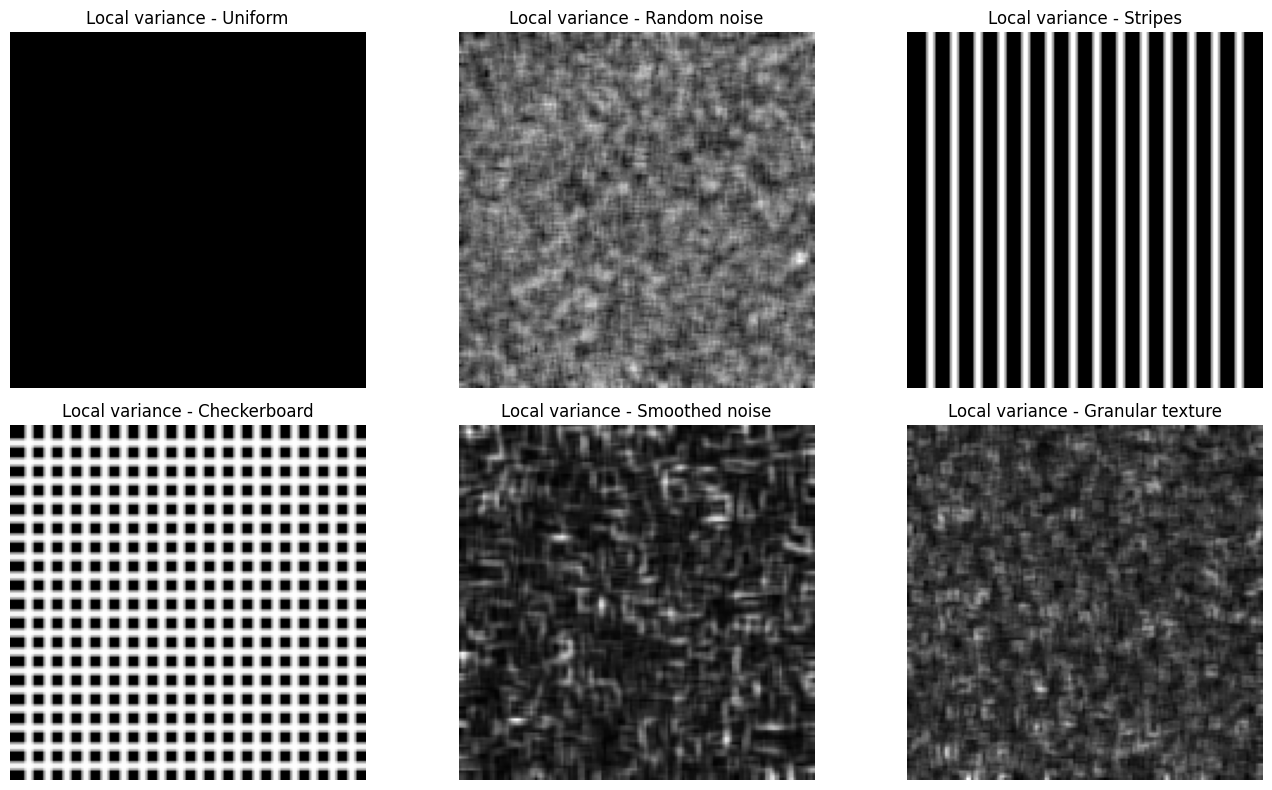

6


In [25]:
variance_maps = [local_variance(img, size=5) for img in images]
variance_titles = [f"Local variance - {title}" for title in titles]

show_images(variance_maps, variance_titles, figsize=(14, 8), save_path="../figures/figures_texture/synthetic_texture_imagenes_01.png")

In [26]:
"""
En algunas imagenes, la textura puede relacionarse con:

- porosidad
- heterogeneidad
- distribución de granos
- microestructura interna
- regiones compactas frente a regiones fragmentadas

"""

'\nEn algunas imagenes, la textura puede relacionarse con:\n\n- porosidad\n- heterogeneidad\n- distribución de granos\n- microestructura interna\n- regiones compactas frente a regiones fragmentadas\n\n'

In [27]:
def extract_random_patches(image, patch_size=32, n_patches=40):
    patches = []
    h, w = image.shape
    
    for _ in range(n_patches):
        i = np.random.randint(0, h - patch_size)
        j = np.random.randint(0, w - patch_size)
        patch = image[i:i+patch_size, j:j+patch_size]
        patches.append(patch)
    
    return patches

In [28]:
texture_dict = {
    0: ("Uniform", uniform),
    1: ("Random noise", noise),
    2: ("Stripes", stripes),
    3: ("Checkerboard", checkerboard),
    4: ("Smoothed noise", smoothed_noise),
    5: ("Granular texture", granular),
}

X = []
y = []

for label, (name, img) in texture_dict.items():
    patches = extract_random_patches(img, patch_size=32, n_patches=60)
    for patch in patches:
        feats = extract_basic_texture_features(patch)
        X.append(list(feats.values()))
        y.append(label)

X = np.array(X)
y = np.array(y)

feature_names = list(extract_basic_texture_features(uniform).keys())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)

X shape: (360, 7)
y shape: (360,)
Features: ['mean', 'std', 'min', 'max', 'entropy', 'local_variance_mean', 'local_variance_std']


In [29]:
"""
Train/Test Split and Random Forest Classification, ahora entrenaremos un simple Random Forest classifier utilizando las texture features.

Este no es un modelo altamente optimizado. El objetivo es mostrar cómo se puede convertir la textura en descriptores numéricos y utilizarlos en un flujo de trabajo de aprendizaje automático estándar.
"""

'\nTrain/Test Split and Random Forest Classification, ahora entrenaremos un simple Random Forest classifier utilizando las texture features.\n\nEste no es un modelo altamente optimizado. El objetivo es mostrar cómo se puede convertir la textura en descriptores numéricos y utilizarlos en un flujo de trabajo de aprendizaje automático estándar.\n'

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [31]:
label_names = [texture_dict[i][0] for i in sorted(texture_dict.keys())]

print(classification_report(y_test, y_pred, target_names=label_names))

                  precision    recall  f1-score   support

         Uniform       1.00      1.00      1.00        15
    Random noise       1.00      1.00      1.00        15
         Stripes       1.00      1.00      1.00        15
    Checkerboard       1.00      1.00      1.00        15
  Smoothed noise       1.00      1.00      1.00        15
Granular texture       1.00      1.00      1.00        15

        accuracy                           1.00        90
       macro avg       1.00      1.00      1.00        90
    weighted avg       1.00      1.00      1.00        90



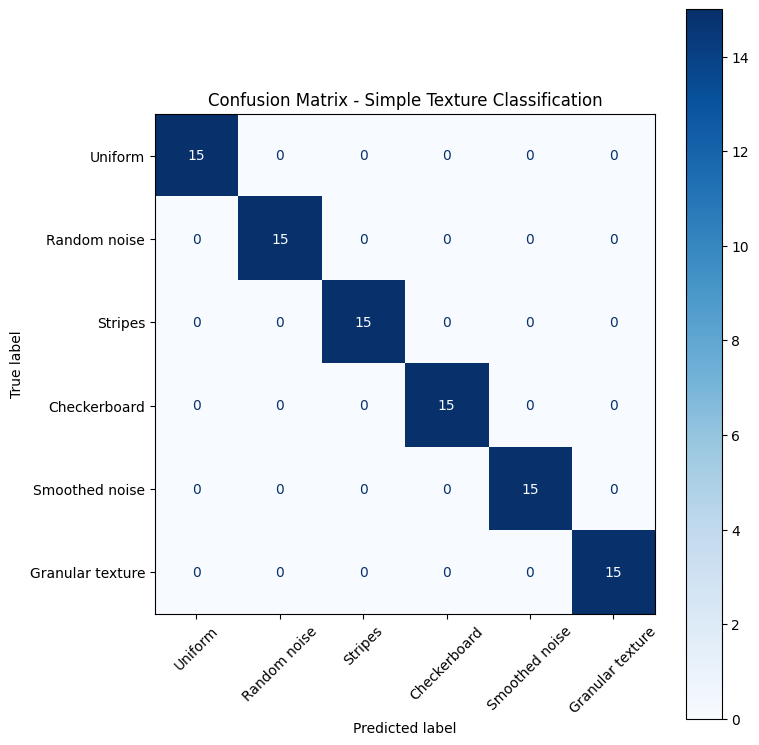

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=label_names, cmap='Blues', ax=ax
)
plt.title("Confusion Matrix - Simple Texture Classification")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/figures_texture/syntetic_image_Confusion_Matrix_Simple_Texture_Classification.png", dpi=300, bbox_inches="tight")
plt.show()